In [2]:
import sys
sys.path.append("..")

In [3]:
import numpy as np
from feature_analysis.feature_extract import FeatureExtractManager

In [4]:
kernels_dataset = np.load("../Kernels_datasets_numpy/kernel_dataset_4.npy", allow_pickle=True).item()
feature_manager = FeatureExtractManager(kernels_dataset)
df_features = feature_manager.extract_all_to_dataframe()

Iniciando extracción radiómica (First-Order, GLCM, LDOP-Gradients)...
  -> Minando características para clase: Bleeding (2884 parches)
  -> Minando características para clase: Ischemia (2884 parches)
  -> Minando características para clase: Normal (2884 parches)
--------------------------------------------------
EXTRACCIÓN COMPLETADA.
Dataset estructurado final: 8652 filas (ejemplos) x 15 columnas (features + label)
--------------------------------------------------


In [5]:
feature_list = ['variance', 'glcm_correlation',     # Obtenida de análisis preliminares
                'energy_1st', 'glcm_entropy', 
                'skewness','kurtosis']


--- RANKING DE CARACTERÍSTICAS ---
        Caracteristica  Score_Final  Info_Mutua  RF_Importancia
0             variance     1.000000    0.315456        0.128660
1     glcm_correlation     0.954523    0.299481        0.123474
2           energy_1st     0.608987    0.155818        0.093154
3              mean_hu     0.560650    0.144551        0.085311
4         glcm_entropy     0.542911    0.165601        0.072161
5             kurtosis     0.509199    0.145564        0.071658
6             skewness     0.491574    0.091744        0.089074
7          glcm_energy     0.469528    0.153520        0.058205
8    ldop_grad_90_mean     0.334045    0.076243        0.054860
9   ldop_grad_135_mean     0.288936    0.076213        0.043265
10   ldop_grad_45_mean     0.282012    0.065958        0.045666
11    glcm_homogeneity     0.271098    0.048924        0.049805
12       glcm_contrast     0.245279    0.040448        0.046618
13    ldop_grad_0_mean     0.228992    0.051087        0.038088


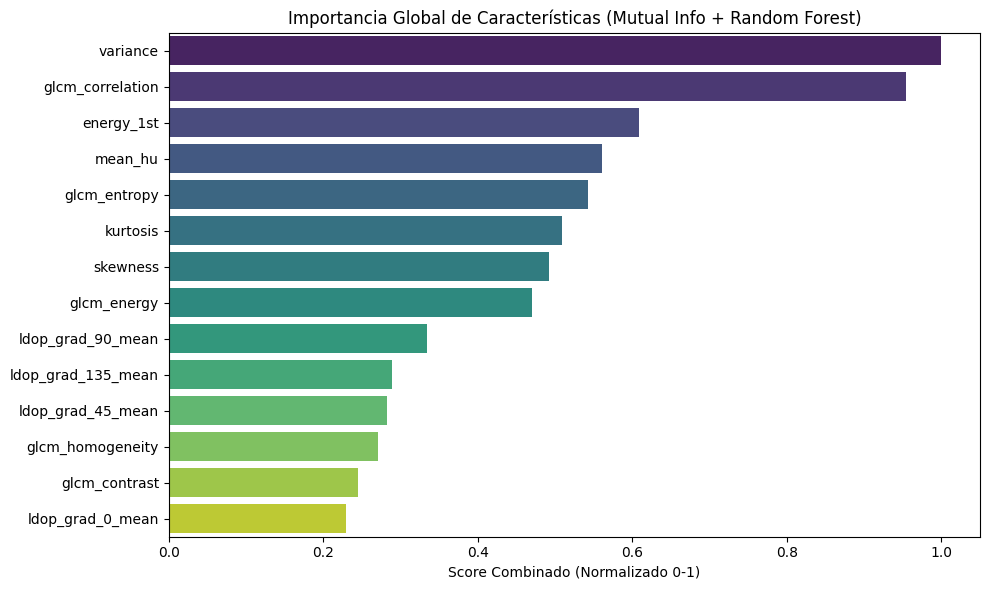

Calculando matriz de correlación cruzada...


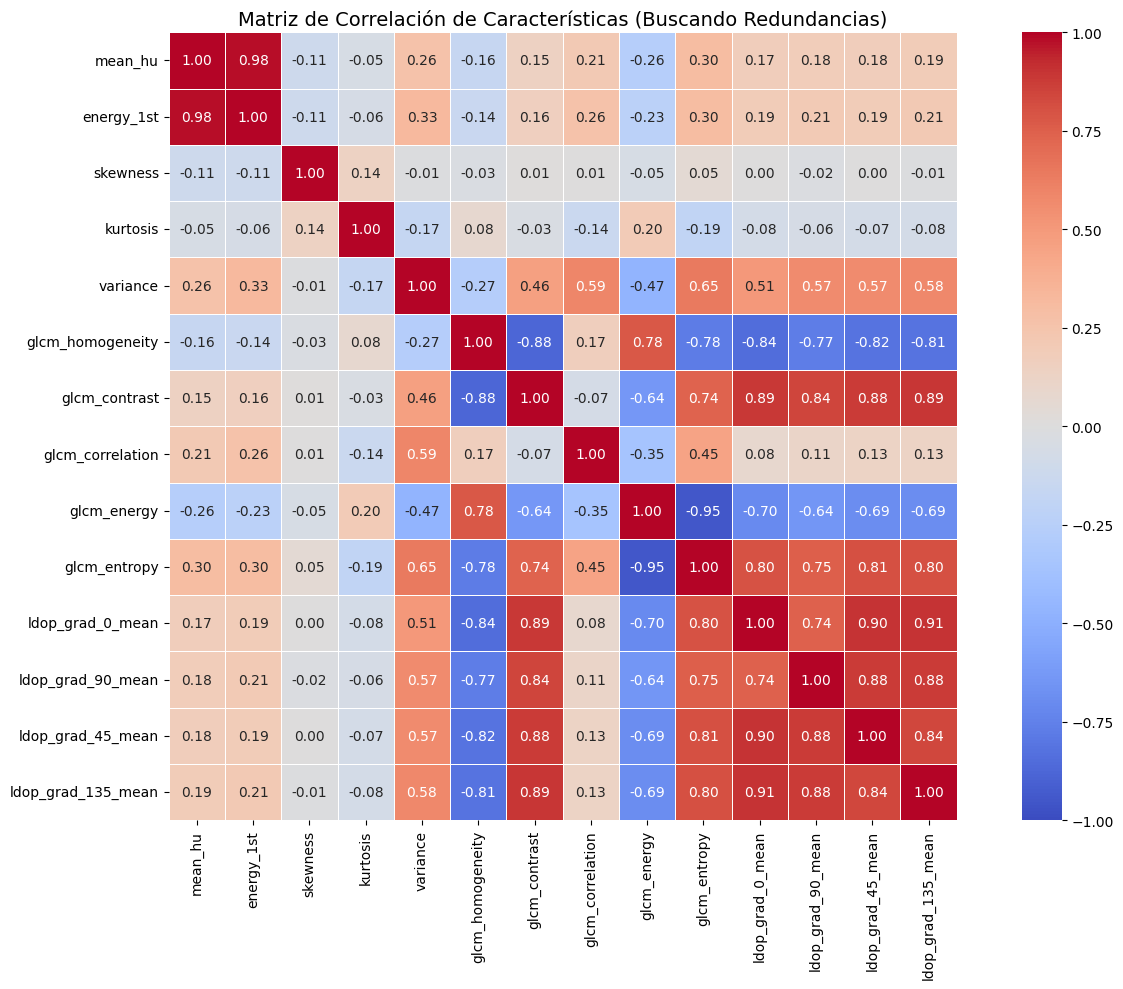

In [6]:
from feature_evaluation.feature_evaluator import FeatureEvaluator
evaluator = FeatureEvaluator(df_features, analysis=True)

In [7]:
ranking = evaluator.rank_feature_combinations(feature_list, max_size=6)

Analizando combinaciones de '['variance', 'glcm_correlation', 'energy_1st', 'glcm_entropy', 'skewness', 'kurtosis']'...

--- TOP 5 MEJORES COMBINACIONES ---
    num_features                                           features  accuracy
61             5  glcm_correlation, energy_1st, glcm_entropy, sk...  0.756210
62             6  variance, glcm_correlation, energy_1st, glcm_e...  0.754477
56             5  variance, glcm_correlation, energy_1st, glcm_e...  0.751011
58             5  variance, glcm_correlation, energy_1st, skewne...  0.744656
42             4   variance, glcm_correlation, energy_1st, skewness  0.742923
51             4  glcm_correlation, energy_1st, glcm_entropy, sk...  0.742923
47             4       variance, energy_1st, glcm_entropy, skewness  0.738879
60             5  variance, energy_1st, glcm_entropy, skewness, ...  0.737146
49             4           variance, energy_1st, skewness, kurtosis  0.714038
43             4   variance, glcm_correlation, energy_1st, kurt

In [8]:
best_features_kernel_1 = ['glcm_correlation', 'energy_1st', 'glcm_entropy', 'skewness', 'kurtosis']
models = evaluator.run_models_benchmark(best_features_kernel_1)

--------------------------------------------------
INICIANDO BENCHMARK DE MODELOS
--------------------------------------------------
Datos de Entrenamiento: 6921 parches
Datos de Prueba (Test): 1731 parches

--- Random Forest ---
Precisión Global (Accuracy): 75.22%
..............................
--- Gradient Boosting (XGBoost lite) ---
Precisión Global (Accuracy): 74.18%
..............................
--- Support Vector Machine (SVM) ---
Precisión Global (Accuracy): 49.68%
..............................
--- Naïve Bayes ---
Precisión Global (Accuracy): 49.97%
..............................

GANADOR DEL BENCHMARK: Random Forest con 75.22% de precisión.


In [9]:
best_features_kernel_2 = ['variance', 'glcm_correlation', 'energy_1st', 'glcm_entropy', 'skewness', 'kurtosis']
models = evaluator.run_models_benchmark(best_features_kernel_2)

--------------------------------------------------
INICIANDO BENCHMARK DE MODELOS
--------------------------------------------------
Datos de Entrenamiento: 6921 parches
Datos de Prueba (Test): 1731 parches

--- Random Forest ---
Precisión Global (Accuracy): 75.85%
..............................
--- Gradient Boosting (XGBoost lite) ---
Precisión Global (Accuracy): 74.75%
..............................
--- Support Vector Machine (SVM) ---
Precisión Global (Accuracy): 49.80%
..............................
--- Naïve Bayes ---
Precisión Global (Accuracy): 55.00%
..............................

GANADOR DEL BENCHMARK: Random Forest con 75.85% de precisión.


In [10]:
best_features_kernel_3 = ['variance', 'glcm_correlation', 'energy_1st', 'glcm_entropy', 'skewness', 'kurtosis']
models = evaluator.run_models_benchmark(best_features_kernel_3)

--------------------------------------------------
INICIANDO BENCHMARK DE MODELOS
--------------------------------------------------
Datos de Entrenamiento: 6921 parches
Datos de Prueba (Test): 1731 parches

--- Random Forest ---
Precisión Global (Accuracy): 75.85%
..............................
--- Gradient Boosting (XGBoost lite) ---
Precisión Global (Accuracy): 74.75%
..............................
--- Support Vector Machine (SVM) ---
Precisión Global (Accuracy): 49.80%
..............................
--- Naïve Bayes ---
Precisión Global (Accuracy): 55.00%
..............................

GANADOR DEL BENCHMARK: Random Forest con 75.85% de precisión.


In [11]:
best_features_kernel_4 = ['glcm_correlation', 'energy_1st', 'glcm_entropy', 'skewness', 'kurtosis']
models = evaluator.run_models_benchmark(best_features_kernel_4)

--------------------------------------------------
INICIANDO BENCHMARK DE MODELOS
--------------------------------------------------
Datos de Entrenamiento: 6921 parches
Datos de Prueba (Test): 1731 parches

--- Random Forest ---
Precisión Global (Accuracy): 75.22%
..............................
--- Gradient Boosting (XGBoost lite) ---
Precisión Global (Accuracy): 74.18%
..............................
--- Support Vector Machine (SVM) ---
Precisión Global (Accuracy): 49.68%
..............................
--- Naïve Bayes ---
Precisión Global (Accuracy): 49.97%
..............................

GANADOR DEL BENCHMARK: Random Forest con 75.22% de precisión.
